In [21]:
# Import Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [4]:
# Import Dataset
df=pd.read_csv('breast_cancer.csv')
df.head(2)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [6]:
# Drop Id column
df=df.drop(columns='id', axis=1)

In [7]:
# Extract Input and output feature
X=df.drop(columns='diagnosis', axis=1)
y=df['diagnosis']

In [9]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=2)

In [11]:
# Scale the dataset
scale=StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

In [26]:
# Train the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict the model
y_pred=knn.predict(X_test)

# Findout the accuracy
print('The accuracy of KNN model:', accuracy_score(y_pred, y_test))

The accuracy of KNN model: 0.9736842105263158


In [20]:
# Try to find out best N_neighbours

scores=[]
for i in range (1,16):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred=knn.predict(X_test)
    scores.append(accuracy_score(y_pred, y_test))
scores

[0.956140350877193,
 0.9736842105263158,
 0.9912280701754386,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9649122807017544,
 0.9649122807017544]

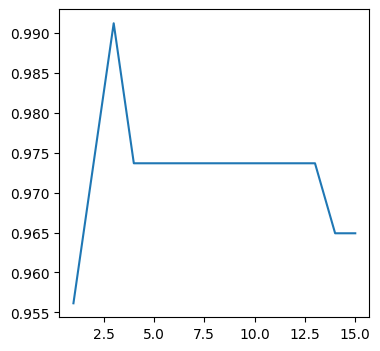

In [25]:
# Draw the plot to visualize the value
plt.figure(figsize=(4,4))
plt.plot(range(1,16), scores)

In [ ]:
# The best value of n_neighbours=3

In [27]:
# So again train the model with n_neighbours=3
# Train the model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict the model
y_pred=knn.predict(X_test)

# Findout the accuracy
print('The accuracy of KNN model:', accuracy_score(y_pred, y_test))

The accuracy of KNN model: 0.9912280701754386
